In [ ]:
import psi4
import numpy as np

# Set Psi4 options
psi4.set_memory('2 GB')
psi4.set_options({
    'basis': '6-31G*',
    'scf_type': 'df'
})

# Define base butane geometry (Z-matrix for easy dihedral manipulation)
butane_template = """
0 1
C
C 1 1.54
C 2 1.54 1 112.0
C 3 1.54 2 112.0 1 {phi}
H 1 1.09 2 109.5 3 180.0
H 1 1.09 2 109.5 3 60.0
H 1 1.09 2 109.5 3 -60.0
H 2 1.09 3 109.5 1 180.0
H 2 1.09 3 109.5 1 60.0
H 3 1.09 4 109.5 2 180.0
H 3 1.09 4 109.5 2 60.0
H 4 1.09 3 109.5 2 -60.0
H 4 1.09 3 109.5 2 60.0
H 4 1.09 3 109.5 2 180.0
"""

# Define scan range (0 to 360 degrees)
angles = np.linspace(0, 360, 37)  # every 10 degrees
energies = []

for phi in angles:
    print(f"Calculating for dihedral = {phi:.1f} deg")

    # Create molecule with current dihedral
    mol = psi4.geometry(butane_template.format(phi=phi))

    # Compute energy (no optimization)
    energy = psi4.energy("scf", molecule=mol)

    energies.append(energy)

# Convert to relative energies (kcal/mol)
energies = np.array(energies)
energies -= energies.min()
energies *= 627.509  # Hartree → kcal/mol

# Print results
print("\nAngle (deg)   Energy (kcal/mol)")
for angle, energy in zip(angles, energies):
    print(f"{angle:8.1f}   {energy:12.4f}")

In [3]:
energies

array([19.35814914, 19.60091662, 18.45729056, 16.96697248, 15.83194053,
       15.17835809, 14.95691488, 15.18564734, 15.84080079, 16.68436083,
       17.28513277, 17.24070119, 16.3671437 , 14.71580997, 12.50109724,
        9.99806745,  7.45876479,  5.07752955,  3.00389693,  1.37478397,
        0.33085922,  0.        ,  0.4563075 ,  1.67497012,  3.50210053,
        5.65696609,  7.77690309,  9.50870824, 10.62771912, 11.12347234,
       11.18957814, 11.15342974, 11.44928467, 12.56894597, 14.7406163 ,
       17.42442881, 19.35814911])

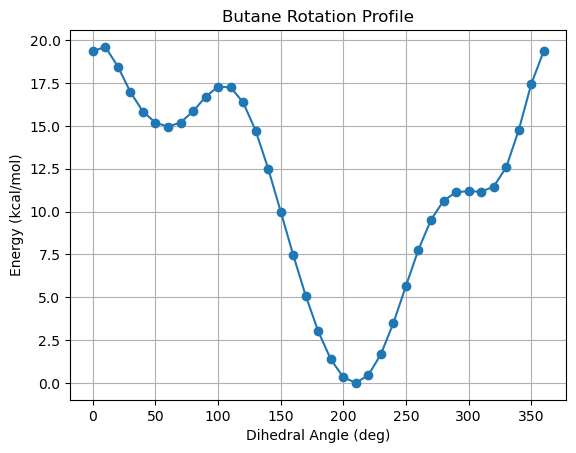

In [5]:

import matplotlib.pyplot as plt

plt.plot(angles, energies, marker='o')
plt.xlabel("Dihedral Angle (deg)")
plt.ylabel("Energy (kcal/mol)")
plt.title("Butane Rotation Profile")
plt.grid()
plt.show()


In [6]:
import psi4
import numpy as np

# Set Psi4 options

psi4.core.set_output_file("butane_scan.log", False)

psi4.set_memory('2 GB')
psi4.set_num_threads(8)
print(f"Threads in use: {psi4.get_num_threads()}")

psi4.set_options({
    'print': 1,
    'scf__print': 0,
    'optking__print': 1,
    'basis': 'STO-3G',
#    'basis': '6-31G*',
    'scf_type': 'df',
    'optking__frozen_dihedral': '1 2 3 4'
    })

# Define base butane geometry (Z-matrix for easy dihedral manipulation)
butane_template = """
0 1
C
C 1 1.54
C 2 1.54 1 112.0
C 3 1.54 2 112.0 1 {phi}
H 1 1.09 2 109.5 3 180.0
H 1 1.09 2 109.5 3 60.0
H 1 1.09 2 109.5 3 -60.0
H 2 1.09 3 109.5 1 180.0
H 2 1.09 3 109.5 1 60.0
H 3 1.09 4 109.5 2 180.0
H 3 1.09 4 109.5 2 60.0
H 4 1.09 3 109.5 2 -60.0
H 4 1.09 3 109.5 2 60.0
H 4 1.09 3 109.5 2 180.0
"""

# Define scan range (0 to 360 degrees)
angles = np.linspace(0, 360, 37)  # every 10 degrees
energies = []

for phi in angles:
    print(f"Calculating for dihedral = {phi:.1f} deg")

    # Create molecule with current dihedral
    mol = psi4.geometry(butane_template.format(phi=phi))

    # Compute energy (no optimization)
        
    energy = psi4.optimize("hf", molecule=mol, return_wfn=False)


    energies.append(energy)

# Convert to relative energies (kcal/mol)
energies = np.array(energies)
energies -= energies.min()
energies *= 627.509  # Hartree → kcal/mol

# Print results
print("\nAngle (deg)   Energy (kcal/mol)")
for angle, energy in zip(angles, energies):
    print(f"{angle:8.1f}   {energy:12.4f}")


energies = np.array(energies)
energies_rel = (energies - energies.min()) * 627.509

# Write data to file
for angle, e_h, e_kcal in zip(angles, energies, energies_rel):
    data_log.write(f"{angle:8.1f}    {e_h:16.8f}    {e_kcal:12.4f}\n")

data_log.close()

print("\nScan complete.")
print("Psi4 log file: butane_scan.log")
print("Energy data file: butane_scan_data.txt")


Threads in use: 8
Calculating for dihedral = 0.0 deg


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.62e-03

	Change in internal coordinate of 5.89e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 7.11e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 9.32e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 6.34e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 3.
	Change in internal coordinate of 1.00e+00 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 1.22e+00 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.83e-03

	Change in internal coordinate of 5.04e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for s

Optimizer: Optimization complete!
Calculating for dihedral = 10.0 deg


	Change in internal coordinate of 5.95e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 7.18e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 9.41e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 6.37e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 3.
	Change in internal coordinate of 1.01e+00 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 1.23e+00 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 5.01e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 4.
	Change in internal coordinate of 8.48e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 3.
	Change in internal coordinate of 1.22e+00 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 1.4

Optimizer: Optimization complete!
Calculating for dihedral = 20.0 deg


...

	Change in internal coordinate of 5.85e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 7.01e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 9.23e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 6.25e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 3.
	Change in internal coordinate of 9.87e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 1.21e+00 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 2.76e-03

	Change in internal coordinate of 8.35e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 3.
	Change in internal coordinate of 1.20e+00 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in inte

Optimizer: Optimization complete!
Calculating for dihedral = 360.0 deg


	Previous geometry is closer to target in internal coordinates, so using that one.

	Best geometry has RMS(Delta(q)) = 3.62e-03

	Change in internal coordinate of 5.89e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 7.11e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 9.32e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 6.34e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 3.
	Change in internal coordinate of 1.00e+00 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 2.
	Change in internal coordinate of 1.22e+00 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 1.
	Change in internal coordinate of 5.04e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 4.
	Change in internal coordinate of 8.47e-01 exceeds limit of 5.00e-01.
	Skipping Hessian update for step 3.
	Change in inte

Optimizer: Optimization complete!

Angle (deg)   Energy (kcal/mol)
     0.0         5.6002
    10.0         5.2860
    20.0         4.4524
    30.0         3.3477
    40.0         2.2488
    50.0         1.3926
    60.0         0.9196
    70.0         0.8582
    80.0         1.1812
    90.0         1.8190
   100.0         2.5751
   110.0         3.1738
   120.0         3.3952
   130.0         3.1543
   140.0         2.5157
   150.0         1.6603
   160.0         0.8219
   170.0         0.2187
   180.0         0.0000
   190.0         0.2186
   200.0         0.8219
   210.0         1.6603
   220.0         2.5156
   230.0         3.1543
   240.0         3.3951
   250.0         3.1736
   260.0         2.5751
   270.0         1.8190
   280.0         1.1814
   290.0         0.8580
   300.0         0.9194
   310.0         1.3925
   320.0         2.2489
   330.0         3.3477
   340.0         4.4524
   350.0         5.2859
   360.0         5.6002


NameError: name 'data_log' is not defined

In [2]:
import psi4

psi4.get_num_threads()

1